# **Forecasting Germany's Electricity Demand**

In [1]:
# --- Environment setup -------------------------------------------------------
# Install anything missing (safe to re-run; does nothing when already installed).
import importlib.util
import subprocess
import sys


def ensure(module_name, pip_name=None):
    """Install `pip_name` quietly if `module_name` cannot be imported."""
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               pip_name or module_name])


for module_name, pip_name in [("seaborn", None), ("statsmodels", None),
                              ("sklearn", "scikit-learn"), ("holidays", None),
                              ("requests", None), ("scipy", None),
                              ("tensorflow", None)]:
    ensure(module_name, pip_name)

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import holidays
from scipy import signal, stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")  # SARIMA grid search emits many convergence notes
sns.set_theme(style="ticks", palette="deep")
print("Environment ready.")

Environment ready.


In [2]:
# --- Configuration -------------------------------------------------------------
from dataclasses import dataclass


@dataclass(frozen=True)
class Config:
    """All knobs for the case study live here so nothing is hard-coded downstream."""
    local_csv: str = "time_series_60min_singleindex.csv"
    opsd_url: str = ("https://data.open-power-system-data.org/time_series/"
                     "2020-10-06/time_series_60min_singleindex.csv")
    load_col: str = "DE_load_actual_entsoe_transparency"
    start_date: str = "2015-01-01"          # keep data from here to end of file (Oct 2020)
    test_weeks: int = 104                    # 2-year forecast horizon
    seasonal_period: int = 52                # weeks per year
    artifacts_dir: str = "artifacts"
    temp_cache_csv: str = "berlin_temperature_daily.csv"
    berlin_lat: float = 52.52
    berlin_lon: float = 13.41
    quick_grid: bool = False                 # full mandated grid p,q in [0,6] (set True only for a quick trial)


CFG = Config()
os.makedirs(CFG.artifacts_dir, exist_ok=True)
print(f"Config loaded. Test horizon = {CFG.test_weeks} weeks, "
      f"seasonal period m = {CFG.seasonal_period}.")

Config loaded. Test horizon = 104 weeks, seasonal period m = 52.


## **Part 1  How do we load and shape the data?**

In [3]:
class DemandSeries:
    """Loads the OPSD hourly load file and exposes hourly / daily / weekly views.

    Units: hourly = MW (equivalently MWh per hour), daily = GWh, weekly = TWh.
    """

    def __init__(self, cfg):
        self.cfg = cfg
        self.hourly = None   # MW, tz-aware Europe/Berlin
        self.daily = None    # GWh, tz-naive daily index
        self.weekly = None   # TWh, tz-naive Sunday-ending weekly index

    def load(self):
        """Read the CSV locally if present, otherwise download from OPSD."""
        usecols = ["utc_timestamp", self.cfg.load_col]
        try:
            raw = pd.read_csv(self.cfg.local_csv, usecols=usecols)
            print(f"Loaded local copy: {self.cfg.local_csv}")
        except (FileNotFoundError, ValueError):
            print("Local file not found — downloading from OPSD (this can take a while)...")
            raw = pd.read_csv(self.cfg.opsd_url, usecols=usecols)
        ts = pd.to_datetime(raw["utc_timestamp"], utc=True)
        series = pd.Series(raw[self.cfg.load_col].values, index=ts, name="load_mw")
        series = series.tz_convert("Europe/Berlin")
        series = series[series.index >= pd.Timestamp(self.cfg.start_date, tz="Europe/Berlin")]
        self.hourly = series
        n_missing = int(series.isna().sum())
        print(f"Hourly series: {len(series)} rows, "
              f"{series.index.min():%Y-%m-%d} to {series.index.max():%Y-%m-%d}, "
              f"{n_missing} missing hourly values.")
        return self

    def build_daily(self):
        """Sum hourly MW to daily GWh and repair short gaps by interpolation."""
        hours_per_day = self.hourly.resample("D").count()
        daily_gwh = self.hourly.resample("D").sum() / 1e3
        daily_gwh[hours_per_day == 0] = np.nan          # fully empty days become NaN
        n_gaps = int(daily_gwh.isna().sum())
        daily_gwh = daily_gwh.interpolate(method="linear", limit=2)
        daily_gwh.index = daily_gwh.index.tz_localize(None)
        self.daily = daily_gwh.rename("daily_gwh")
        print(f"Daily series: {len(daily_gwh)} days, {n_gaps} empty days interpolated "
              f"(linear, limit 2 consecutive days).")
        return self

    def build_weekly(self):
        """Rebuild weekly TWh totals from the repaired daily series."""
        days_per_week = self.daily.resample("W").count()
        weekly_twh = self.daily.resample("W").sum() / 1e3
        complete = days_per_week == 7
        n_dropped = int((~complete).sum())
        self.weekly = weekly_twh[complete].rename("weekly_twh")
        print(f"Weekly series: {len(self.weekly)} complete weeks "
              f"({n_dropped} boundary weeks with fewer than 7 days dropped).")
        return self


demand = DemandSeries(CFG).load().build_daily().build_weekly()

Loaded local copy: time_series_60min_singleindex.csv
Hourly series: 50401 rows, 2015-01-01 to 2020-10-01, 1 missing hourly values.
Daily series: 2101 days, 0 empty days interpolated (linear, limit 2 consecutive days).
Weekly series: 299 complete weeks (2 boundary weeks with fewer than 7 days dropped).


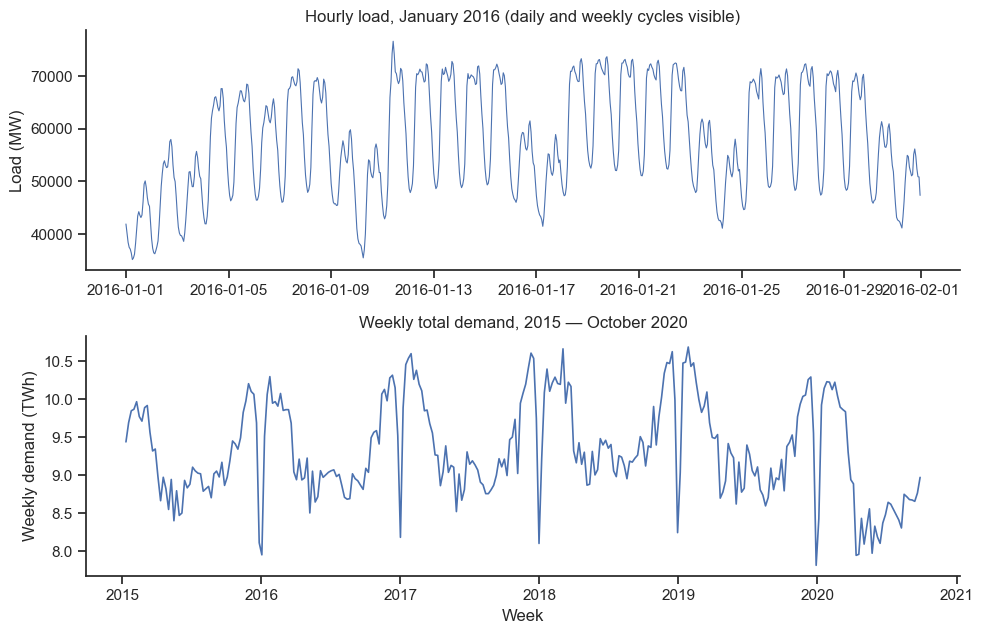

count    299.000
mean       9.325
std        0.629
min        7.813
25%        8.880
50%        9.216
75%        9.861
max       10.685
Name: weekly_twh, dtype: float64


In [4]:
# --- Initial time series plots ---------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=False)

# One month of hourly data to show the within-day and within-week structure.
sample = demand.hourly.loc["2016-01-01":"2016-01-31"]
axes[0].plot(sample.index, sample.values, linewidth=0.8)
axes[0].set_title("Hourly load, January 2016 (daily and weekly cycles visible)")
axes[0].set_ylabel("Load (MW)")

axes[1].plot(demand.weekly.index, demand.weekly.values, linewidth=1.2)
axes[1].set_title("Weekly total demand, 2015 — October 2020")
axes[1].set_ylabel("Weekly demand (TWh)")
axes[1].set_xlabel("Week")

plt.tight_layout()
sns.despine()
plt.show()

print(demand.weekly.describe().round(3))

## **Part 1 (EDA) — How strong is the yearly cycle?**

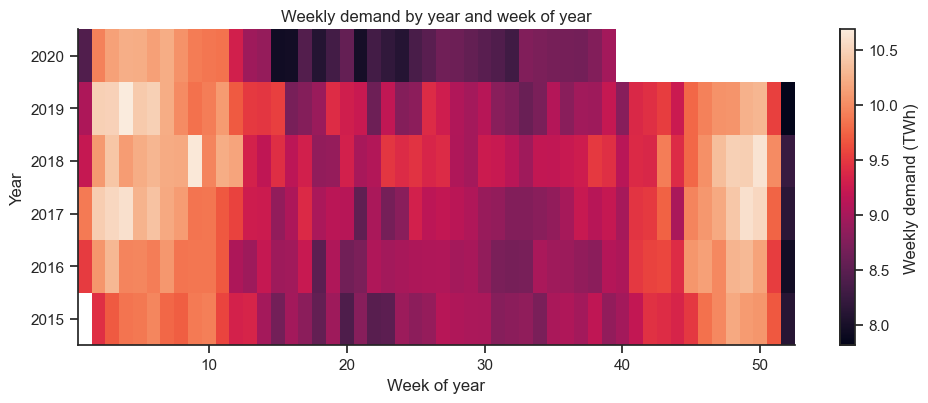

In [5]:
# --- Year x week-of-year heatmap of weekly demand --------------------------------
heat = demand.weekly.to_frame("twh")
heat["year"] = heat.index.year
heat["week"] = heat.index.isocalendar().week.astype(int).clip(upper=52)
pivot = heat.pivot_table(index="year", columns="week", values="twh")

plt.figure(figsize=(10, 4.2))
mesh = plt.pcolormesh(pivot.columns, pivot.index, pivot.values, shading="nearest")
plt.colorbar(mesh, label="Weekly demand (TWh)")
plt.xlabel("Week of year")
plt.ylabel("Year")
plt.title("Weekly demand by year and week of year")
plt.tight_layout()
sns.despine()
plt.show()

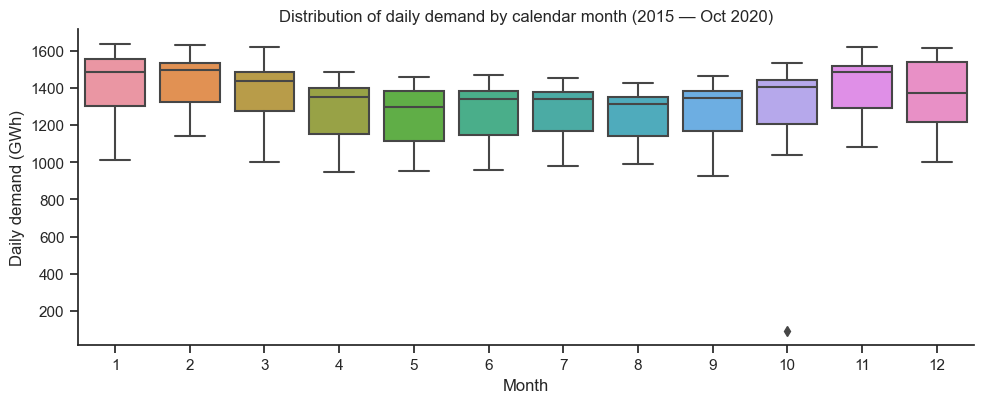

In [6]:
# --- Monthly boxplots of daily totals ---------------------------------------------
daily_df = demand.daily.to_frame("gwh")
daily_df["month"] = daily_df.index.month

plt.figure(figsize=(10, 4.2))
sns.boxplot(data=daily_df, x="month", y="gwh")
plt.xlabel("Month")
plt.ylabel("Daily demand (GWh)")
plt.title("Distribution of daily demand by calendar month (2015 — Oct 2020)")
plt.tight_layout()
sns.despine()
plt.show()

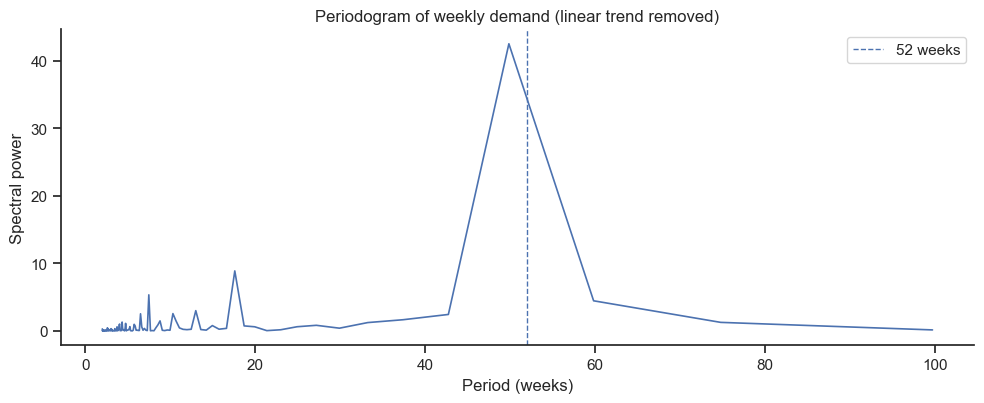

Strongest periods (weeks) by spectral power:
49.8    42.539
17.6     8.887
7.5      5.343
59.8     4.461
13.0     3.001
dtype: float64


In [7]:
# --- Periodogram: which cycle lengths carry the power? ----------------------------
freqs, power = signal.periodogram(demand.weekly.values, detrend="linear")
periods = np.divide(1.0, freqs, out=np.full_like(freqs, np.inf), where=freqs > 0)

plt.figure(figsize=(10, 4.2))
mask = (periods >= 2) & (periods <= 120)
plt.plot(periods[mask], power[mask], linewidth=1.2)
plt.axvline(52, linestyle="--", linewidth=1, label="52 weeks")
plt.xlabel("Period (weeks)")
plt.ylabel("Spectral power")
plt.title("Periodogram of weekly demand (linear trend removed)")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

top = pd.Series(power[mask], index=np.round(periods[mask], 1)).nlargest(5)
print("Strongest periods (weeks) by spectral power:")
print(top.round(3))

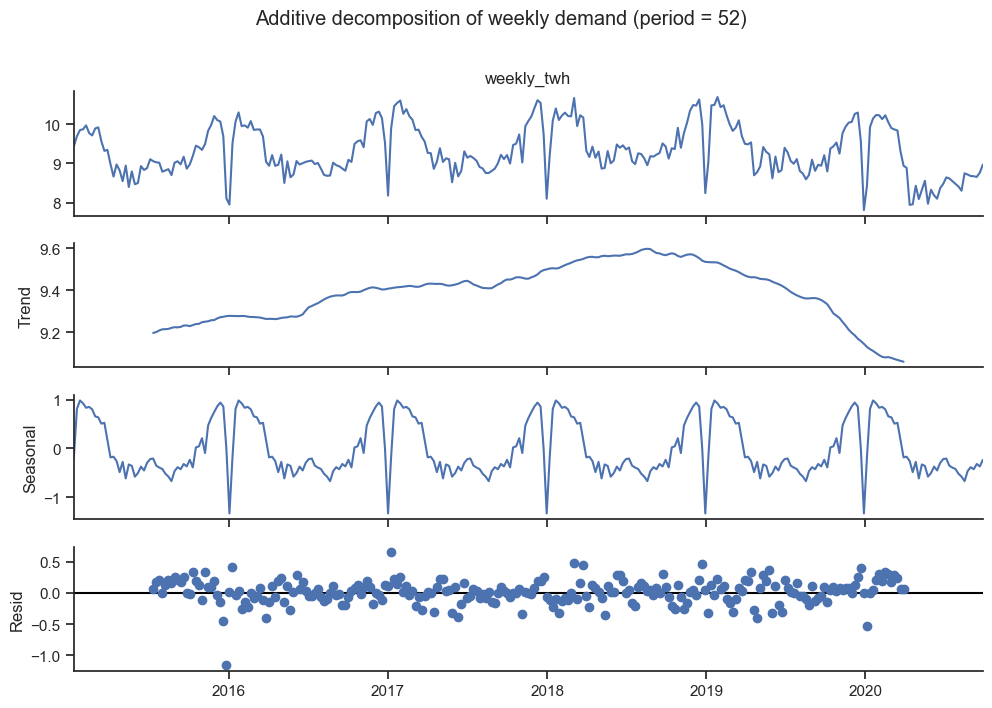

Peak-to-trough seasonal amplitude: 2.32 TWh per week.


In [8]:
# --- Classical additive decomposition ---------------------------------------------
decomp = seasonal_decompose(demand.weekly, model="additive", period=CFG.seasonal_period)
fig = decomp.plot()
fig.set_size_inches(10, 7)
fig.suptitle("Additive decomposition of weekly demand (period = 52)", y=1.01)
plt.tight_layout()
sns.despine()
plt.show()

seasonal_amp = float(decomp.seasonal.max() - decomp.seasonal.min())
print(f"Peak-to-trough seasonal amplitude: {seasonal_amp:.2f} TWh per week.")

ADF test summary (null hypothesis: series is non-stationary):
                              ADF statistic  p-value  n obs
variant                                                    
level                                -3.934  0.00180    290
first difference                     -6.984  0.00000    290
seasonal difference (lag 52)         -1.798  0.38134    235
first + seasonal difference          -7.717  0.00000    235


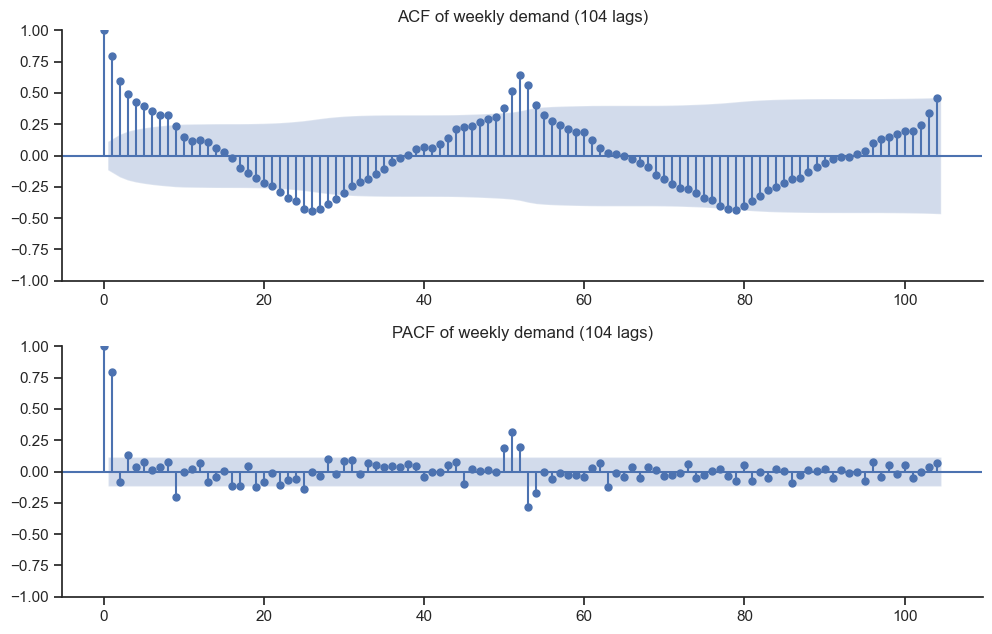

In [9]:
# --- ADF tests across differencing variants ---------------------------------------
variants = {
    "level": demand.weekly,
    "first difference": demand.weekly.diff(),
    "seasonal difference (lag 52)": demand.weekly.diff(CFG.seasonal_period),
    "first + seasonal difference": demand.weekly.diff(CFG.seasonal_period).diff(),
}

rows = []
for name, series in variants.items():
    clean = series.dropna()
    stat, pvalue, usedlag, nobs, _, _ = adfuller(clean, autolag="AIC")
    rows.append({"variant": name, "ADF statistic": round(stat, 3),
                 "p-value": round(pvalue, 5), "n obs": nobs})

adf_table = pd.DataFrame(rows).set_index("variant")
print("ADF test summary (null hypothesis: series is non-stationary):")
print(adf_table)

# --- ACF and PACF out to 104 lags (two seasonal cycles) -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5))
plot_acf(demand.weekly, lags=104, ax=axes[0])
axes[0].set_title("ACF of weekly demand (104 lags)")
plot_pacf(demand.weekly, lags=104, ax=axes[1], method="ywm")
axes[1].set_title("PACF of weekly demand (104 lags)")
plt.tight_layout()
sns.despine()
plt.show()

## **Part 2  How well do the simplest possible forecasts do?**

In [10]:
class Scoreboard:
    """Accumulates model forecasts on a fixed test window and scores them.

    Metrics: RMSE (in the units of the series), MAPE (%), and weighted MAPE
    (wMAPE = sum|error| / sum|actual|, expressed in %).
    """

    def __init__(self, actual):
        self.actual = actual
        self.forecasts = {}   # model name -> forecast series on the test index

    def add(self, name, forecast):
        """Register a forecast, aligned to the test index."""
        self.forecasts[name] = pd.Series(forecast, index=self.actual.index[:len(forecast)]) \
            if not isinstance(forecast, pd.Series) else forecast.reindex(self.actual.index)
        print(f"Scoreboard: added '{name}'.")

    @staticmethod
    def rmse(y, yhat):
        return float(np.sqrt(np.mean(np.square(y - yhat))))

    @staticmethod
    def mape(y, yhat):
        return float(np.mean(np.abs((y - yhat) / y)) * 100)

    @staticmethod
    def wmape(y, yhat):
        return float(np.abs(y - yhat).sum() / np.abs(y).sum() * 100)

    def _aligned(self, name):
        pair = pd.concat([self.actual.rename("y"),
                          self.forecasts[name].rename("yhat")], axis=1).dropna()
        return pair["y"], pair["yhat"]

    def table(self):
        """Return the metrics table as a DataFrame (one row per model)."""
        rows = {}
        for name in self.forecasts:
            y, yhat = self._aligned(name)
            rows[name] = {"RMSE (TWh)": self.rmse(y, yhat),
                          "MAPE (%)": self.mape(y, yhat),
                          "wMAPE (%)": self.wmape(y, yhat)}
        return pd.DataFrame(rows).T.round(3)

    def plot_all(self, train_tail=None, save_path=None):
        """Plot actuals plus every registered forecast; optionally save to disk."""
        plt.figure(figsize=(10, 4.2))
        if train_tail is not None:
            plt.plot(train_tail.index, train_tail.values,
                     linewidth=1.0, label="Train (tail)")
        plt.plot(self.actual.index, self.actual.values,
                 linewidth=2.0, label="Actual (test)")
        for name, forecast in self.forecasts.items():
            plt.plot(forecast.index, forecast.values, linewidth=1.1, label=name)
        plt.ylabel("Weekly demand (TWh)")
        plt.xlabel("Week")
        plt.title("All model forecasts vs actual weekly demand (2-year test window)")
        plt.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        sns.despine()
        if save_path is not None:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"Figure saved to {save_path}")
        plt.show()


# --- Train / test split (last 104 weeks held out) -----------------------------------
weekly = demand.weekly
test = weekly.iloc[-CFG.test_weeks:]
train = weekly.iloc[:-CFG.test_weeks]
board = Scoreboard(test)
print(f"Train: {len(train)} weeks ({train.index.min():%Y-%m-%d} to {train.index.max():%Y-%m-%d})")
print(f"Test:  {len(test)} weeks ({test.index.min():%Y-%m-%d} to {test.index.max():%Y-%m-%d})")

Train: 195 weeks (2015-01-11 to 2018-09-30)
Test:  104 weeks (2018-10-07 to 2020-09-27)


Scoreboard: added 'Mean'.
Scoreboard: added 'Naive'.
Scoreboard: added 'Seasonal naive'.
Scoreboard: added 'Drift'.


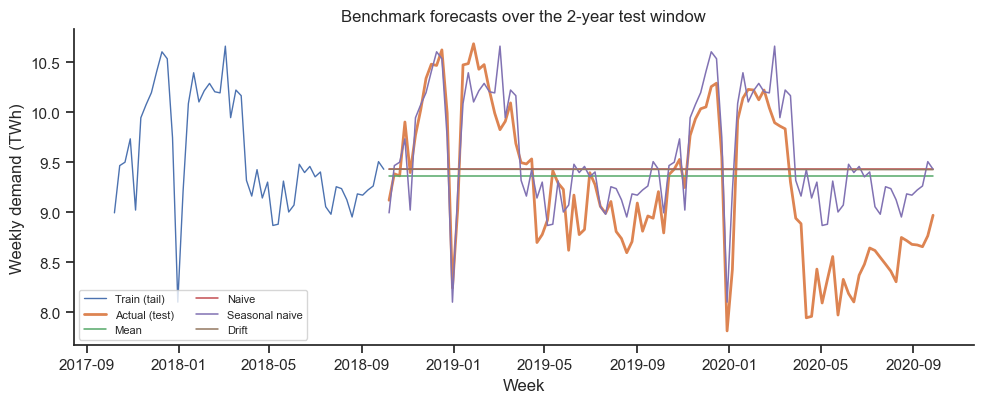

                RMSE (TWh)  MAPE (%)  wMAPE (%)
Mean                 0.740     6.986      6.881
Naive                0.753     7.165      7.007
Seasonal naive       0.501     4.349      4.143
Drift                0.752     7.155      6.999


In [11]:
# --- The four benchmark forecasts ---------------------------------------------------
h = len(test)
m = CFG.seasonal_period

fc_mean = pd.Series(train.mean(), index=test.index)
fc_naive = pd.Series(train.iloc[-1], index=test.index)

last_cycle = train.iloc[-m:].values
reps = int(np.ceil(h / m))
fc_snaive = pd.Series(np.tile(last_cycle, reps)[:h], index=test.index)

slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
fc_drift = pd.Series(train.iloc[-1] + slope * np.arange(1, h + 1), index=test.index)

for name, forecast in [("Mean", fc_mean), ("Naive", fc_naive),
                       ("Seasonal naive", fc_snaive), ("Drift", fc_drift)]:
    board.add(name, forecast)

plt.figure(figsize=(10, 4.2))
plt.plot(train.iloc[-m:].index, train.iloc[-m:].values, linewidth=1.0, label="Train (tail)")
plt.plot(test.index, test.values, linewidth=2.0, label="Actual (test)")
for name in ["Mean", "Naive", "Seasonal naive", "Drift"]:
    plt.plot(test.index, board.forecasts[name].values, linewidth=1.1, label=name)
plt.ylabel("Weekly demand (TWh)")
plt.xlabel("Week")
plt.title("Benchmark forecasts over the 2-year test window")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
sns.despine()
plt.show()

print(board.table())

## **Part 3 Can a SARIMA model beat the seasonal naive?**

In [12]:
def sarima_grid_search(train_series, cfg):
    """Fit the SARIMA grid in parallel and rank candidates by AICc (computed from AIC)."""
    from joblib import Parallel, delayed

    max_pq = 2 if cfg.quick_grid else 6
    m = cfg.seasonal_period
    candidates = [(p, d, q, P, Q)
                  for p in range(0, max_pq + 1)
                  for d in range(0, 3)
                  for q in range(0, max_pq + 1)
                  for P in (0, 1)
                  for Q in (0, 1)]
    print(f"Searching {len(candidates)} candidate models "
          f"(quick_grid={cfg.quick_grid}) on all CPU cores -- progress prints below.")

    def fit_one(p, d, q, P, Q):
        # concentrate_scale folds the error variance out of the optimisation,
        # which speeds every fit up without changing the model being compared
        try:
            res = SARIMAX(train_series,
                          order=(p, d, q),
                          seasonal_order=(P, 1, Q, m),
                          enforce_stationarity=False,
                          enforce_invertibility=False,
                          concentrate_scale=True).fit(disp=False, maxiter=100)
            k = len(res.params)
            n = int(res.nobs)
            if n - k - 1 > 0:
                aicc = res.aic + (2 * k * (k + 1)) / (n - k - 1)
            else:
                aicc = np.inf
            return {"p": p, "d": d, "q": q, "P": P, "Q": Q,
                    "AIC": res.aic, "AICc": aicc}
        except Exception:
            return None                      # numerically infeasible corner: skip

    raw = Parallel(n_jobs=-1, verbose=10)(delayed(fit_one)(*c) for c in candidates)
    records = [r for r in raw if r is not None]
    print(f"Successfully fitted {len(records)} of {len(candidates)} candidates.")
    return pd.DataFrame(records).sort_values("AICc").reset_index(drop=True)


grid_results = sarima_grid_search(train, CFG)
print("\nTop 10 models by AICc:")
print(grid_results.head(10).round(2))

best_row = grid_results.iloc[0]
best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))
best_seasonal = (int(best_row["P"]), 1, int(best_row["Q"]), CFG.seasonal_period)
print(f"\nSelected model: SARIMA{best_order}x{best_seasonal}  (AICc = {best_row['AICc']:.2f})")


Searching 588 candidate models (quick_grid=False) on all CPU cores -- progress prints below.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/lib/python3.12/site-pac

Successfully fitted 585 of 588 candidates.

Top 10 models by AICc:
   p  d  q  P  Q   AIC  AICc
0  3  1  5  0  1 -6.20 -5.22
1  2  1  5  0  1 -2.54 -1.77
2  0  1  2  0  1 -0.72 -0.59
3  3  2  6  0  1 -1.02  0.18
4  2  1  6  0  1 -0.76  0.22
5  3  1  6  0  1 -0.91  0.29
6  3  0  5  0  1 -0.58  0.40
7  4  1  5  0  1 -0.47  0.73
8  1  1  1  0  1  0.70  0.83
9  5  0  3  0  1  0.23  1.21

Selected model: SARIMA(3, 1, 5)x(0, 1, 1, 52)  (AICc = -5.22)


[Parallel(n_jobs=-1)]: Done 588 out of 588 | elapsed: 25.1min finished


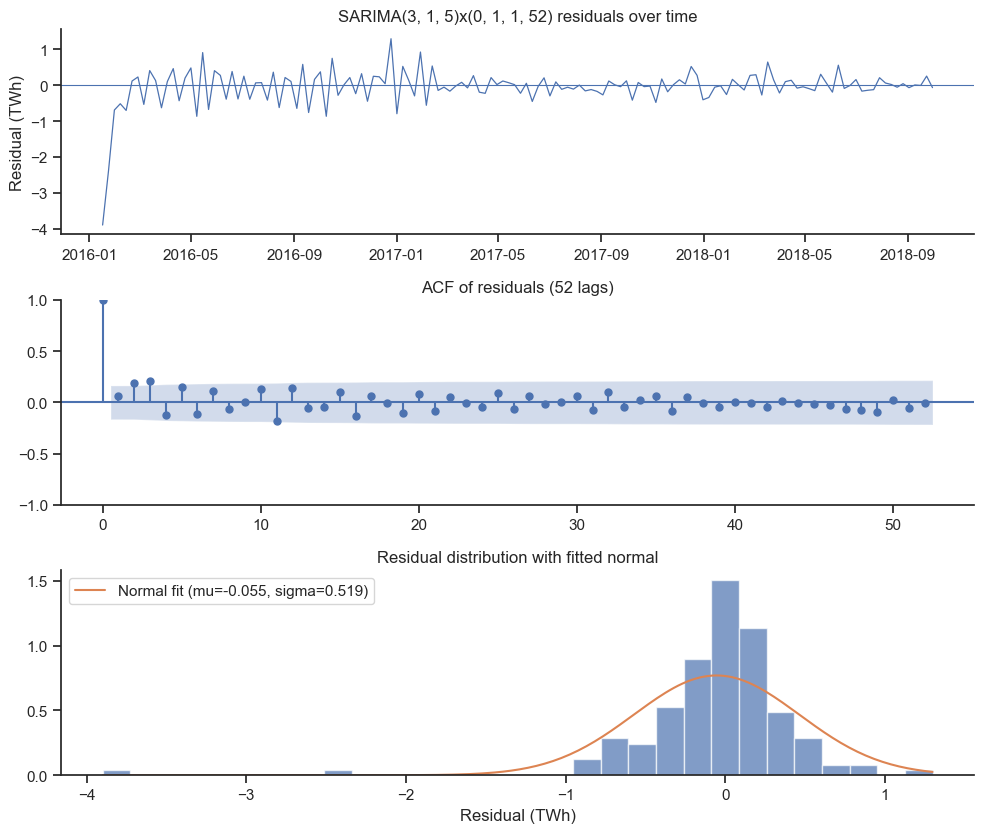

Ljung-Box test on residuals (null: no autocorrelation up to the given lag):
    lb_stat  lb_pvalue
13  32.9202     0.0018
26  45.7095     0.0098
39  53.5529     0.0603


In [13]:
# --- Refit the selected model and inspect residuals ---------------------------------
sarima_res = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                     enforce_stationarity=False, enforce_invertibility=False
                     ).fit(disp=False, maxiter=200)

resid = sarima_res.resid.iloc[CFG.seasonal_period + 1:]   # skip differencing burn-in

fig, axes = plt.subplots(3, 1, figsize=(10, 8.5))
axes[0].plot(resid.index, resid.values, linewidth=0.9)
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title(f"SARIMA{best_order}x{best_seasonal} residuals over time")
axes[0].set_ylabel("Residual (TWh)")

plot_acf(resid, lags=52, ax=axes[1])
axes[1].set_title("ACF of residuals (52 lags)")

axes[2].hist(resid.values, bins=30, density=True, alpha=0.7)
mu, sigma = stats.norm.fit(resid.values)
grid_x = np.linspace(resid.min(), resid.max(), 200)
axes[2].plot(grid_x, stats.norm.pdf(grid_x, mu, sigma), linewidth=1.5,
             label=f"Normal fit (mu={mu:.3f}, sigma={sigma:.3f})")
axes[2].set_title("Residual distribution with fitted normal")
axes[2].set_xlabel("Residual (TWh)")
axes[2].legend()
plt.tight_layout()
sns.despine()
plt.show()

lb = acorr_ljungbox(resid, lags=[13, 26, 39], return_df=True)
print("Ljung-Box test on residuals (null: no autocorrelation up to the given lag):")
print(lb.round(4))

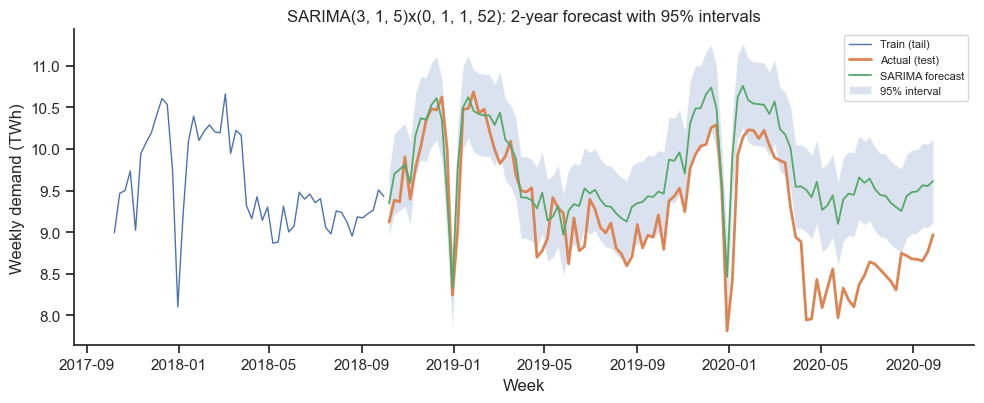

Scoreboard: added 'SARIMA'.
SARIMA RMSE on test: 0.642 TWh | wMAPE: 5.67%


In [14]:
# --- Forecast the last 2 years with confidence intervals -----------------------------
sarima_fc = sarima_res.get_forecast(steps=len(test))
fc_sarima = pd.Series(sarima_fc.predicted_mean.values, index=test.index)
ci = sarima_fc.conf_int(alpha=0.05)

plt.figure(figsize=(10, 4.2))
plt.plot(train.iloc[-CFG.seasonal_period:].index,
         train.iloc[-CFG.seasonal_period:].values, linewidth=1.0, label="Train (tail)")
plt.plot(test.index, test.values, linewidth=2.0, label="Actual (test)")
plt.plot(test.index, fc_sarima.values, linewidth=1.3, label="SARIMA forecast")
plt.fill_between(test.index, ci.iloc[:, 0].values, ci.iloc[:, 1].values,
                 alpha=0.2, label="95% interval")
plt.ylabel("Weekly demand (TWh)")
plt.xlabel("Week")
plt.title(f"SARIMA{best_order}x{best_seasonal}: 2-year forecast with 95% intervals")
plt.legend(fontsize=8)
plt.tight_layout()
sns.despine()
plt.show()

board.add("SARIMA", fc_sarima)
print(f"SARIMA RMSE on test: {board.rmse(test, fc_sarima):.3f} TWh | "
      f"wMAPE: {board.wmape(test, fc_sarima):.2f}%")

## **Part 4 Can temperature explain the winter peaks?**

In [15]:
def fetch_berlin_temperature(cfg):
    """Daily mean temperature for Berlin from the Open-Meteo archive, cached to CSV."""
    if os.path.exists(cfg.temp_cache_csv):
        cached = pd.read_csv(cfg.temp_cache_csv, index_col=0, parse_dates=True)
        print(f"Loaded cached temperature file: {cfg.temp_cache_csv}")
        return cached["temp_c"]
    print("Requesting daily temperature from the Open-Meteo archive API...")
    params = {"latitude": cfg.berlin_lat, "longitude": cfg.berlin_lon,
              "start_date": "2015-01-01", "end_date": "2020-10-31",
              "daily": "temperature_2m_mean", "timezone": "Europe/Berlin"}
    resp = requests.get("https://archive-api.open-meteo.com/v1/archive",
                        params=params, timeout=60)
    resp.raise_for_status()
    payload = resp.json()["daily"]
    temp = pd.Series(payload["temperature_2m_mean"],
                     index=pd.to_datetime(payload["time"]), name="temp_c")
    temp.to_csv(cfg.temp_cache_csv)
    print(f"Downloaded {len(temp)} days and cached to {cfg.temp_cache_csv}.")
    return temp


temp_daily = fetch_berlin_temperature(CFG)
print(temp_daily.describe().round(2))

Requesting daily temperature from the Open-Meteo archive API...
Downloaded 2131 days and cached to berlin_temperature_daily.csv.
count    2131.00
mean       11.03
std         7.64
min        -8.90
25%         4.90
50%        10.60
75%        17.20
max        29.90
Name: temp_c, dtype: float64


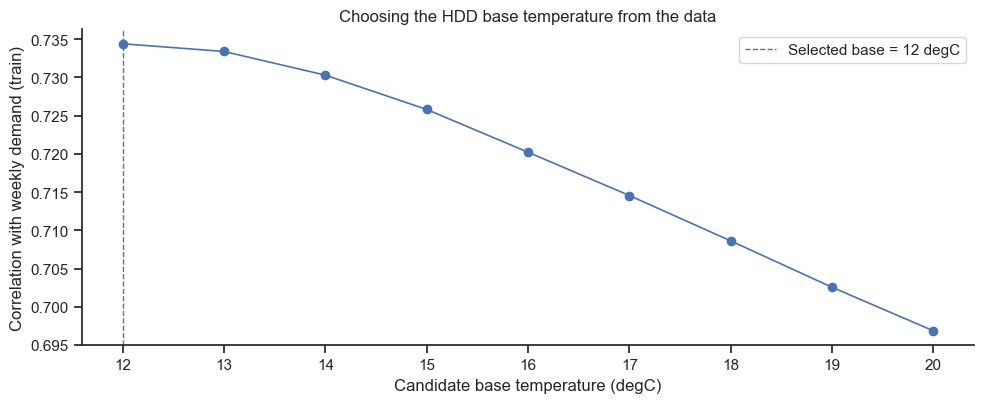

HDD base selected: 12 degC (train correlation = 0.734)
Holiday weeks in test window: 16 of 104


In [16]:
# --- Derive the HDD base temperature from the training data --------------------------
candidate_bases = range(12, 21)
correlations = {}
for base in candidate_bases:
    hdd_weekly = (base - temp_daily).clip(lower=0).resample("W").sum()
    aligned = pd.concat([train.rename("demand"), hdd_weekly.rename("hdd")],
                        axis=1).dropna()          # training window only — no leakage
    correlations[base] = aligned["demand"].corr(aligned["hdd"])

corr_series = pd.Series(correlations)
best_base = int(corr_series.idxmax())

plt.figure(figsize=(10, 4.2))
plt.plot(corr_series.index, corr_series.values, marker="o", linewidth=1.2)
plt.axvline(best_base, linestyle="--", linewidth=1,
            label=f"Selected base = {best_base} degC")
plt.xlabel("Candidate base temperature (degC)")
plt.ylabel("Correlation with weekly demand (train)")
plt.title("Choosing the HDD base temperature from the data")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

hdd_weekly = (best_base - temp_daily).clip(lower=0).resample("W").sum().rename("hdd")

# --- Binary holiday-week flag ---------------------------------------------------------
de_holidays = holidays.Germany(years=range(2015, 2021))
is_holiday_day = pd.Series([day.date() in de_holidays for day in temp_daily.index],
                           index=temp_daily.index)
is_holiday_week = is_holiday_day.resample("W").max().astype(int).rename("is_holiday_week")

exog_all = pd.concat([hdd_weekly, is_holiday_week], axis=1).reindex(weekly.index)
exog_all = exog_all.interpolate(limit=1).fillna(0.0)
exog_train = exog_all.loc[train.index]
exog_test = exog_all.loc[test.index]
print(f"HDD base selected: {best_base} degC "
      f"(train correlation = {corr_series.max():.3f})")
print(f"Holiday weeks in test window: {int(exog_test['is_holiday_week'].sum())} of {len(test)}")

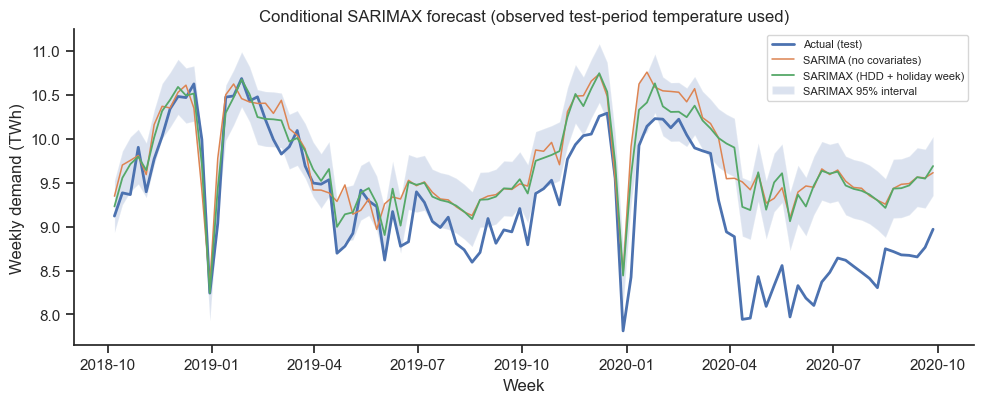

Scoreboard: added 'SARIMAX (HDD + holidays)'.
Exogenous coefficient estimates:
hdd                0.00620
is_holiday_week   -0.33007
dtype: float64

SARIMAX RMSE on test: 0.597 TWh | wMAPE: 5.08%


In [17]:
# --- SARIMAX: same orders as the best SARIMA, plus [hdd, is_holiday_week] ------------
sarimax_res = SARIMAX(train, exog=exog_train, order=best_order,
                      seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False
                      ).fit(disp=False, maxiter=200)

sarimax_fc = sarimax_res.get_forecast(steps=len(test), exog=exog_test)
fc_sarimax = pd.Series(sarimax_fc.predicted_mean.values, index=test.index)
ci_x = sarimax_fc.conf_int(alpha=0.05)

plt.figure(figsize=(10, 4.2))
plt.plot(test.index, test.values, linewidth=2.0, label="Actual (test)")
plt.plot(test.index, fc_sarima.values, linewidth=1.1, label="SARIMA (no covariates)")
plt.plot(test.index, fc_sarimax.values, linewidth=1.3,
         label="SARIMAX (HDD + holiday week)")
plt.fill_between(test.index, ci_x.iloc[:, 0].values, ci_x.iloc[:, 1].values,
                 alpha=0.2, label="SARIMAX 95% interval")
plt.ylabel("Weekly demand (TWh)")
plt.xlabel("Week")
plt.title("Conditional SARIMAX forecast (observed test-period temperature used)")
plt.legend(fontsize=8)
plt.tight_layout()
sns.despine()
plt.show()

board.add("SARIMAX (HDD + holidays)", fc_sarimax)
print("Exogenous coefficient estimates:")
print(sarimax_res.params.filter(items=["hdd", "is_holiday_week"]).round(5))
print(f"\nSARIMAX RMSE on test: {board.rmse(test, fc_sarimax):.3f} TWh | "
      f"wMAPE: {board.wmape(test, fc_sarimax):.2f}%")

## **Part 5  Can a feature-based model learn the calendar directly?**

Random Forest fitted on 91 training weeks with 8 features.
Scoreboard: added 'Random Forest'.


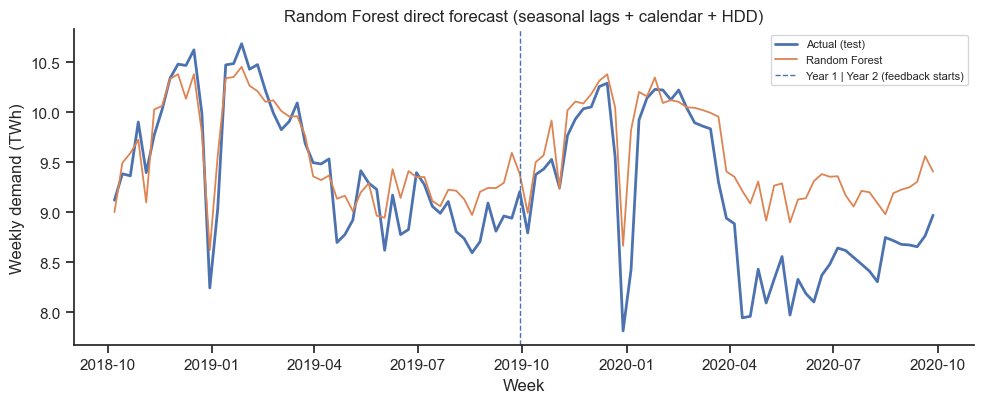

Random Forest RMSE on test: 0.487 TWh | wMAPE: 3.97%


In [18]:
from sklearn.ensemble import RandomForestRegressor


def make_feature_frame(y, hdd, holiday_flag, m=52):
    """Assemble the regression features on the weekly index."""
    X = pd.DataFrame(index=y.index)
    X["lag_52"] = y.shift(m)
    X["lag_104"] = y.shift(2 * m)
    week = X.index.isocalendar().week.astype(float).clip(upper=52)
    for k in (1, 2):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * week / m)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * week / m)
    X["hdd"] = hdd
    X["is_holiday_week"] = holiday_flag
    return X


features = make_feature_frame(weekly, exog_all["hdd"], exog_all["is_holiday_week"])
X_train = features.loc[train.index].dropna()
y_train = train.loc[X_train.index]

rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest fitted on {len(X_train)} training weeks "
      f"with {X_train.shape[1]} features.")

# --- Direct forecast: year 1 uses true lags; year 2 feeds back year-1 predictions ----
X_test = features.loc[test.index].copy()
m = CFG.seasonal_period

X_year1 = X_test.iloc[:m]
pred_year1 = rf.predict(X_year1)

X_year2 = X_test.iloc[m:].copy()
X_year2["lag_52"] = pred_year1[:len(X_year2)]   # block-level feedback of predictions
pred_year2 = rf.predict(X_year2)

fc_rf = pd.Series(np.concatenate([pred_year1, pred_year2]), index=test.index)
board.add("Random Forest", fc_rf)

plt.figure(figsize=(10, 4.2))
plt.plot(test.index, test.values, linewidth=2.0, label="Actual (test)")
plt.plot(test.index, fc_rf.values, linewidth=1.3, label="Random Forest")
plt.axvline(test.index[m - 1], linestyle="--", linewidth=1,
            label="Year 1 | Year 2 (feedback starts)")
plt.ylabel("Weekly demand (TWh)")
plt.xlabel("Week")
plt.title("Random Forest direct forecast (seasonal lags + calendar + HDD)")
plt.legend(fontsize=8)
plt.tight_layout()
sns.despine()
plt.show()

print(f"Random Forest RMSE on test: {board.rmse(test, fc_rf):.3f} TWh | "
      f"wMAPE: {board.wmape(test, fc_rf):.2f}%")

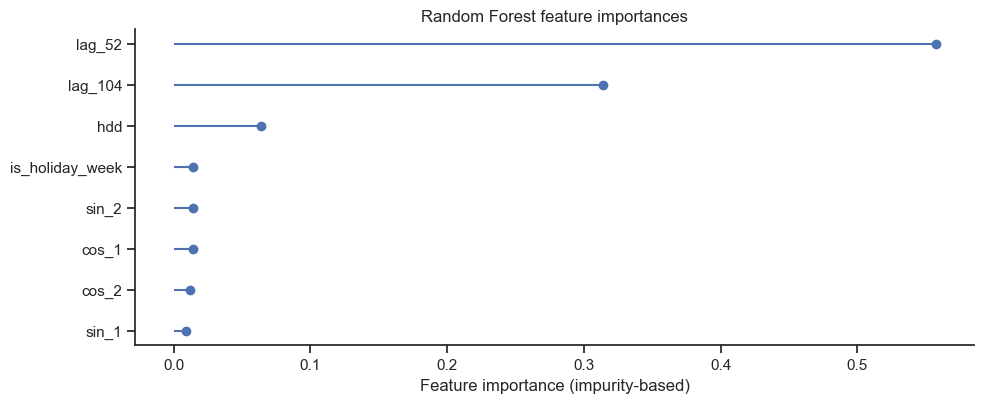

lag_52             0.5574
lag_104            0.3141
hdd                0.0643
is_holiday_week    0.0145
sin_2              0.0144
cos_1              0.0141
cos_2              0.0120
sin_1              0.0092
dtype: float64


In [19]:
# --- Which features does the forest actually use? -------------------------------------
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(10, 4.2))
plt.hlines(y=range(len(importance)), xmin=0, xmax=importance.values, linewidth=1.5)
plt.plot(importance.values, range(len(importance)), "o")
plt.yticks(range(len(importance)), importance.index)
plt.xlabel("Feature importance (impurity-based)")
plt.title("Random Forest feature importances")
plt.tight_layout()
sns.despine()
plt.show()

print(importance.sort_values(ascending=False).round(4))

## **Part 6 Can a neural network exploit the hourly data?**

In [20]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)

LOOKBACK = 240   # hours (10 days)
HORIZON = 24     # direct day-ahead output block

# --- Regular UTC hourly grid (24 rows per day, no DST irregularities) -----------------
hourly = demand.hourly.tz_convert("UTC").tz_localize(None).asfreq("h")
hourly = hourly.interpolate(limit=6).ffill().bfill()

# Split at the start of the weekly test window (weekly labels are Sunday-ending,
# so the window begins 6 days before the first test label).
test_start = (test.index[0] - pd.Timedelta(days=6)).normalize()
hourly_train = hourly[hourly.index < test_start]
hourly_test = hourly[hourly.index >= test_start]
print(f"Hourly train: {len(hourly_train)} h | hourly test: {len(hourly_test)} h "
      f"(test starts {test_start:%Y-%m-%d})")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(hourly_train.values.reshape(-1, 1)).ravel()
test_scaled = scaler.transform(hourly_test.values.reshape(-1, 1)).ravel()


def make_windows(arr, lookback, horizon, stride):
    """Slice a 1-D array into (X, Y) supervised windows."""
    X, Y = [], []
    for start in range(0, len(arr) - lookback - horizon + 1, stride):
        X.append(arr[start:start + lookback])
        Y.append(arr[start + lookback:start + lookback + horizon])
    return np.asarray(X)[..., None], np.asarray(Y)


X_all, Y_all = make_windows(train_scaled, LOOKBACK, HORIZON, stride=24)
split = int(len(X_all) * 0.9)                      # chronological validation split
X_tr, Y_tr = X_all[:split], Y_all[:split]
X_val, Y_val = X_all[split:], Y_all[split:]
print(f"Training windows: {len(X_tr)} | validation windows: {len(X_val)}")


def build_hourly_net(filters, lstm_units, kernel_size):
    """Conv1D + LSTM hybrid (or pure LSTM when filters=0) with a direct 24-hour head."""
    stem = []
    if filters:   # filters=0 drops the convolutional front-end entirely
        stem = [keras.layers.Conv1D(filters, kernel_size, padding="causal",
                                    activation="relu"),
                keras.layers.MaxPooling1D(2)]
    model = keras.Sequential([
        keras.layers.Input(shape=(LOOKBACK, 1)),
        *stem,
        keras.layers.LSTM(lstm_units),
        keras.layers.Dense(HORIZON),
    ])
    model.compile(optimizer="adam", loss="mae")
    return model

Hourly train: 32857 h | hourly test: 17544 h (test starts 2018-10-01)
Training windows: 1223 | validation windows: 136


In [21]:
# --- Hyperparameter search over (filters, LSTM units, kernel size) variants -----------
# The fourth variant sets filters=0: a pure LSTM with no convolutional front-end, so
# the layer design itself (with/without Conv1D stem) is part of the search.
variants = [(32, 48, 6), (16, 32, 4), (48, 64, 8), (0, 48, 0)]
tuning_log = []
best_model, best_val = None, np.inf

for filters, lstm_units, kernel_size in variants:
    print(f"\nTraining variant: filters={filters}, lstm_units={lstm_units}, "
          f"kernel={kernel_size}")
    model = build_hourly_net(filters, lstm_units, kernel_size)
    history = model.fit(
        X_tr, Y_tr,
        validation_data=(X_val, Y_val),
        epochs=20,
        batch_size=256,
        callbacks=[keras.callbacks.EarlyStopping(patience=2,
                                                 restore_best_weights=True)],
        verbose=0,
    )
    val_mae = float(np.min(history.history["val_loss"]))
    tuning_log.append({"filters": filters, "lstm_units": lstm_units,
                       "kernel_size": kernel_size,
                       "epochs_run": len(history.history["loss"]),
                       "val_MAE (scaled)": round(val_mae, 4)})
    print(f"  best val MAE (scaled units): {val_mae:.4f}")
    if val_mae < best_val:
        best_val, best_model = val_mae, model

tuning_table = pd.DataFrame(tuning_log)
print("\nTuning summary:")
print(tuning_table)
print(f"\nSelected variant: val MAE = {best_val:.4f}")


Training variant: filters=32, lstm_units=48, kernel=6


2026-07-04 13:35:21.380413: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-04 13:35:21.380531: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-04 13:35:21.380534: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1783168521.380767 1985043 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783168521.381234 1985043 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-04 13:35:22.230316: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1783168522.235261 1985043 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: 

  best val MAE (scaled units): 0.3005

Training variant: filters=16, lstm_units=32, kernel=4
  best val MAE (scaled units): 0.3673

Training variant: filters=48, lstm_units=64, kernel=8
  best val MAE (scaled units): 0.2191

Training variant: filters=0, lstm_units=48, kernel=0
  best val MAE (scaled units): 0.3736

Tuning summary:
   filters  lstm_units  kernel_size  epochs_run  val_MAE (scaled)
0       32          48            6          20            0.3005
1       16          32            4          20            0.3673
2       48          64            8          20            0.2191
3        0          48            0          20            0.3736

Selected variant: val MAE = 0.2191


  forecasted 100/731 days...
  forecasted 200/731 days...
  forecasted 300/731 days...
  forecasted 400/731 days...
  forecasted 500/731 days...
  forecasted 600/731 days...
  forecasted 700/731 days...

Hourly evaluation over 731 forecast days: RMSE = 9281 MW, MAPE = 13.39%
Scoreboard: added 'Conv1D-LSTM (hourly)'.


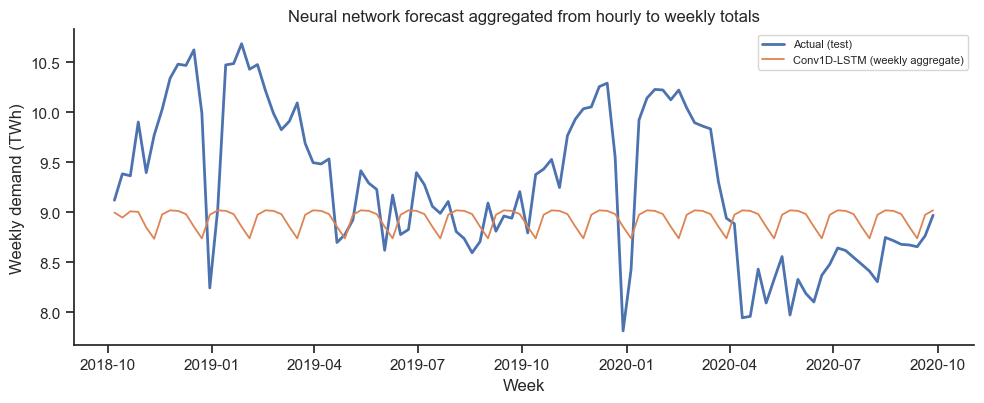

In [22]:
# --- Slide day-by-day across the 2-year test window, feeding predictions back --------
n_days = len(test_scaled) // 24
history_buffer = list(train_scaled[-LOOKBACK:])
preds_scaled = []
for day in range(n_days):
    x = np.asarray(history_buffer[-LOOKBACK:], dtype=np.float32)[None, :, None]
    day_pred = best_model.predict(x, verbose=0)[0]
    preds_scaled.extend(day_pred.tolist())
    history_buffer.extend(day_pred.tolist())      # daily feedback of own predictions
    if (day + 1) % 100 == 0:
        print(f"  forecasted {day + 1}/{n_days} days...")

pred_mw = scaler.inverse_transform(np.asarray(preds_scaled).reshape(-1, 1)).ravel()
pred_hourly = pd.Series(pred_mw, index=hourly_test.index[:len(pred_mw)],
                        name="pred_mw")
actual_hourly = hourly_test.iloc[:len(pred_mw)]

hourly_rmse = float(np.sqrt(np.mean(np.square(actual_hourly.values - pred_hourly.values))))
hourly_mape = float(np.mean(np.abs((actual_hourly.values - pred_hourly.values)
                                   / actual_hourly.values)) * 100)
print(f"\nHourly evaluation over {n_days} forecast days: "
      f"RMSE = {hourly_rmse:.0f} MW, MAPE = {hourly_mape:.2f}%")

# --- Aggregate to weekly TWh for the shared scoreboard --------------------------------
hours_per_week = pred_hourly.resample("W").count()
weekly_pred_twh = (pred_hourly.resample("W").sum() / 1e6)[hours_per_week == 168]
fc_net = weekly_pred_twh.reindex(test.index)
board.add("Conv1D-LSTM (hourly)", fc_net)

plt.figure(figsize=(10, 4.2))
plt.plot(test.index, test.values, linewidth=2.0, label="Actual (test)")
plt.plot(fc_net.index, fc_net.values, linewidth=1.3, label="Conv1D-LSTM (weekly aggregate)")
plt.ylabel("Weekly demand (TWh)")
plt.xlabel("Week")
plt.title("Neural network forecast aggregated from hourly to weekly totals")
plt.legend(fontsize=8)
plt.tight_layout()
sns.despine()
plt.show()

Two best models by wMAPE: ['Random Forest', 'Seasonal naive']

Mean absolute error (TWh) by meteorological season:
model   Random Forest  Seasonal naive
season                               
winter          0.255           0.217
spring          0.439           0.520
summer          0.499           0.529
autumn          0.271           0.259


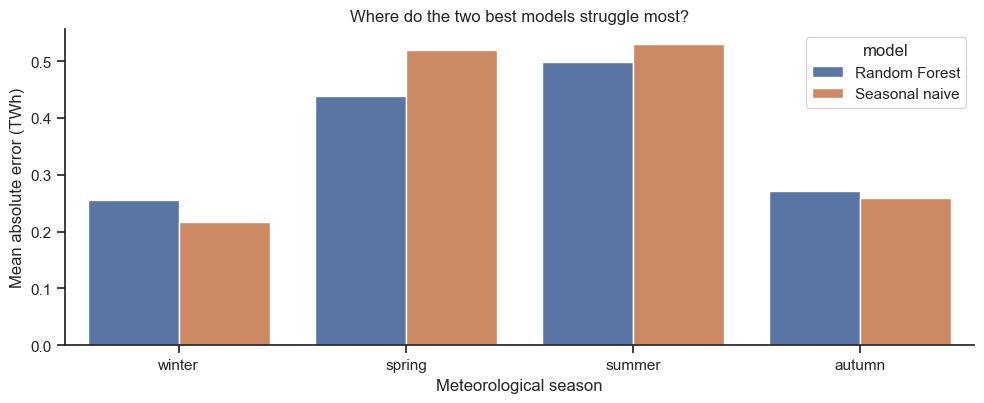

In [23]:
# --- Seasonal (quarterly) error breakdown for the two best models ---------------------
def met_season(month):
    """Map a calendar month to its meteorological season."""
    if month in (12, 1, 2):
        return "winter"
    if month in (3, 4, 5):
        return "spring"
    if month in (6, 7, 8):
        return "summer"
    return "autumn"


ranked = board.table().sort_values("wMAPE (%)")
best_two = list(ranked.index[:2])
print(f"Two best models by wMAPE: {best_two}")

rows = []
for name in best_two:
    y, yhat = board._aligned(name)
    abs_err = (y - yhat).abs()
    for ts, err in abs_err.items():
        rows.append({"model": name, "season": met_season(ts.month),
                     "abs_error_twh": err})

err_df = pd.DataFrame(rows)
season_order = ["winter", "spring", "summer", "autumn"]
summary = (err_df.groupby(["season", "model"])["abs_error_twh"].mean()
           .unstack().reindex(season_order))
print("\nMean absolute error (TWh) by meteorological season:")
print(summary.round(3))

plt.figure(figsize=(10, 4.2))
sns.barplot(data=err_df, x="season", y="abs_error_twh", hue="model",
            order=season_order, errorbar=None)
plt.xlabel("Meteorological season")
plt.ylabel("Mean absolute error (TWh)")
plt.title("Where do the two best models struggle most?")
plt.tight_layout()
sns.despine()
plt.show()

## **Final comparison one plot, one table**

Figure saved to artifacts/comparison_of_models.png


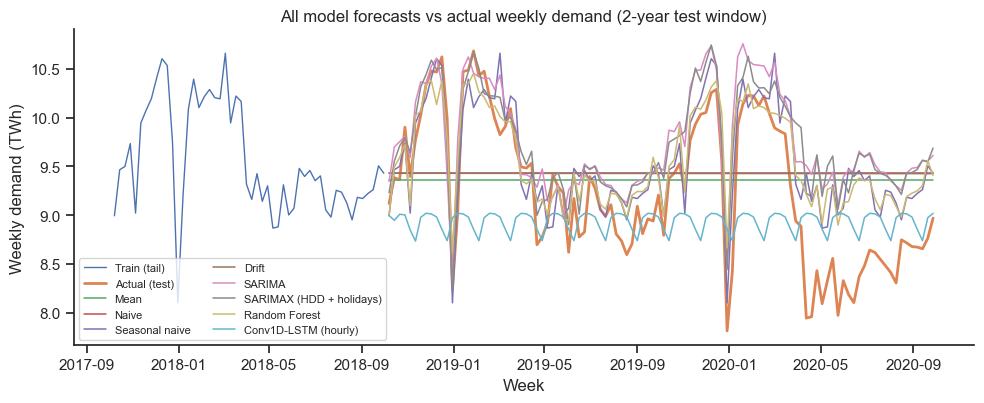

Metrics table saved to artifacts/metrics_summary.csv

                          RMSE (TWh)  MAPE (%)  wMAPE (%)
Random Forest                  0.487     4.212      3.970
Seasonal naive                 0.501     4.349      4.143
SARIMAX (HDD + holidays)       0.597     5.353      5.083
SARIMA                         0.642     5.941      5.673
Mean                           0.740     6.986      6.881
Drift                          0.752     7.155      6.999
Naive                          0.753     7.165      7.007
Conv1D-LSTM (hourly)           0.806     6.870      7.074


In [24]:
# --- Final deliverables ----------------------------------------------------------------
comparison_path = os.path.join(CFG.artifacts_dir, "comparison_of_models.png")
board.plot_all(train_tail=train.iloc[-CFG.seasonal_period:], save_path=comparison_path)

metrics_table = board.table().sort_values("wMAPE (%)")
metrics_path = os.path.join(CFG.artifacts_dir, "metrics_summary.csv")
metrics_table.to_csv(metrics_path)
print(f"Metrics table saved to {metrics_path}\n")
print(metrics_table)